In [2]:
## Credit card fraud detection using machine learning/deep learning techniques with phyton
## implemented data visualization techniques
## implemented feature engineering techniques


In [3]:
# Basic setup
import numpy as np
import pandas as pd
# Basic visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Advanced plots
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import resample

# Classical ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier



In [4]:
%pip install lightgbm
from lightgbm import LGBMClassifier
%pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
from lightgbm import LGBMClassifier
## Deep Learning models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [6]:
#Data Process

df = pd.read_csv("creditcard.csv")

df.head()



print("Shape:", df.shape)
print("Columns:", df.columns)


df.info()
df.describe()

# Missing values check
print(df.isnull().sum().sum())


Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-n

Class
0    284315
1       492
Name: count, dtype: int64


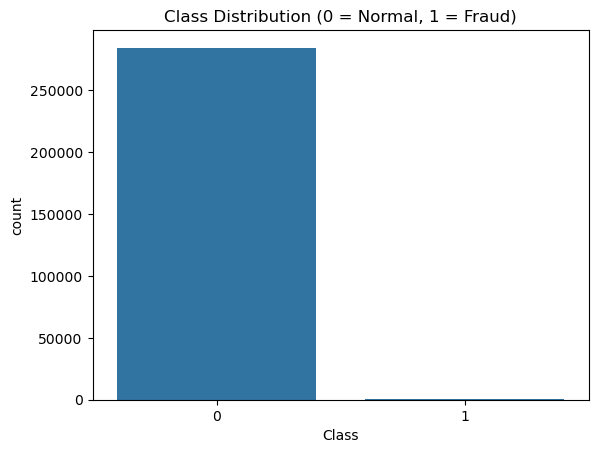

In [7]:

print(df['Class'].value_counts())


sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()


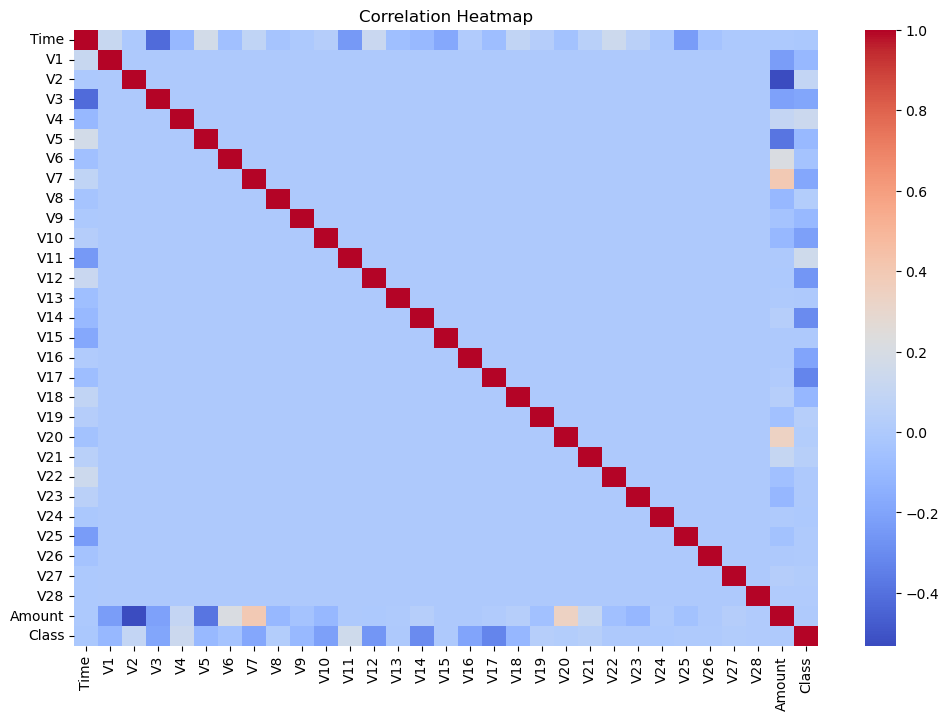

In [8]:
    # Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [9]:

scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))


df = df.drop(['Time','Amount'], axis=1)
# Reorder columns
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount','scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)


X = df.drop('Class', axis=1)
y = df['Class']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
## ML models training and evaluation

# Logistic Regression baseline
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# Random Forest baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]


In [11]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)

def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    print(f"==== {model_name} ====")
    print(classification_report(y_true, y_pred, digits=4))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_true, y_prob):.4f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(recall, precision, label=model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.show()


==== Logistic Regression ====
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

ROC-AUC: 0.9572835078037969


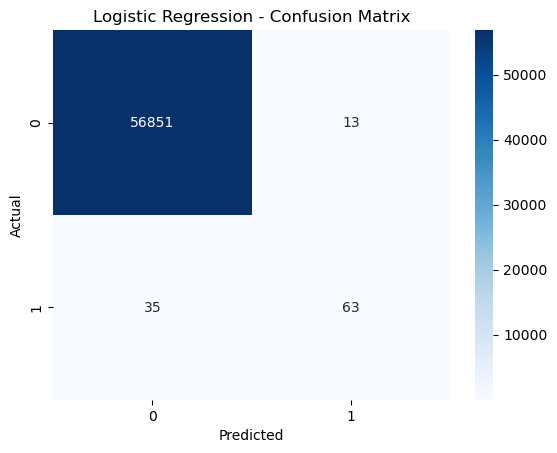

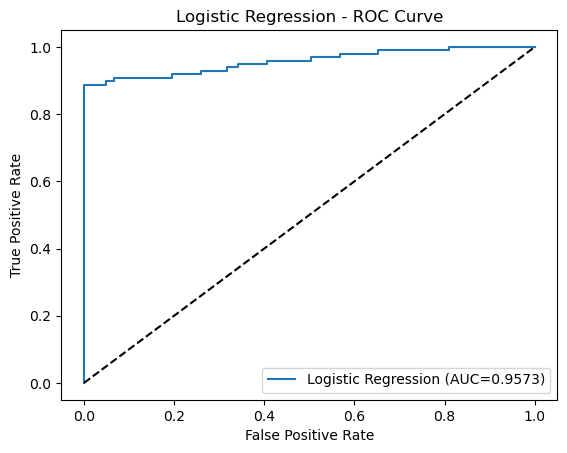

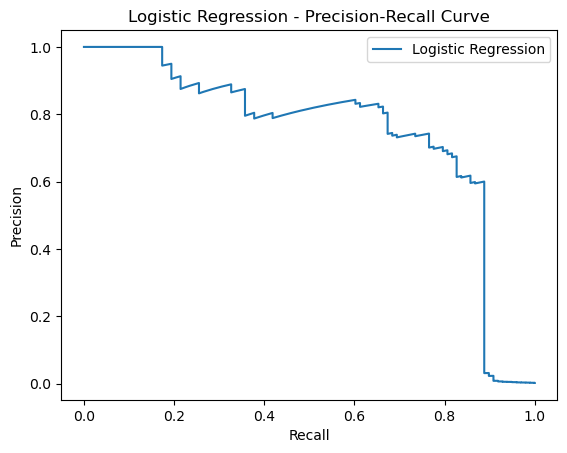

==== Random Forest ====
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9405    0.8061    0.8681        98

    accuracy                         0.9996     56962
   macro avg     0.9701    0.9030    0.9340     56962
weighted avg     0.9996    0.9996    0.9996     56962

ROC-AUC: 0.9476690894421923


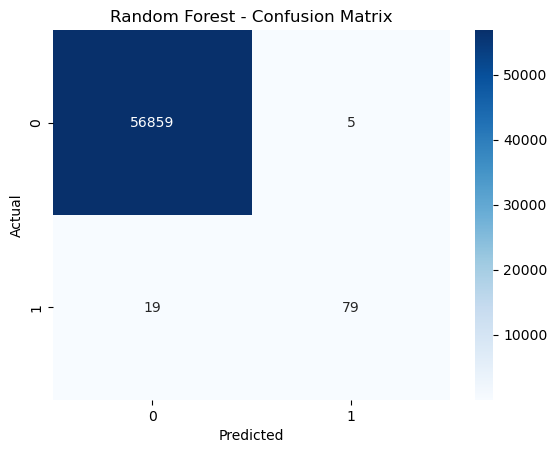

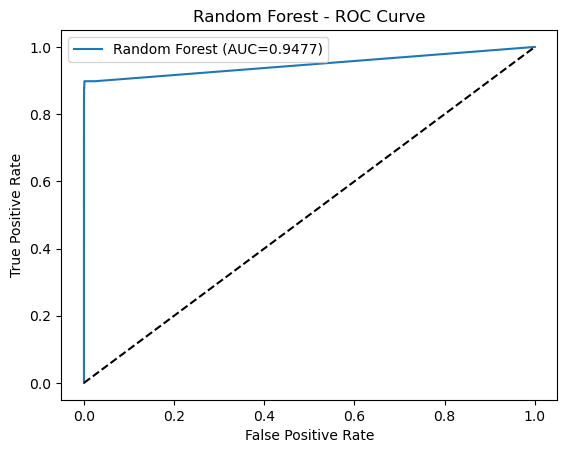

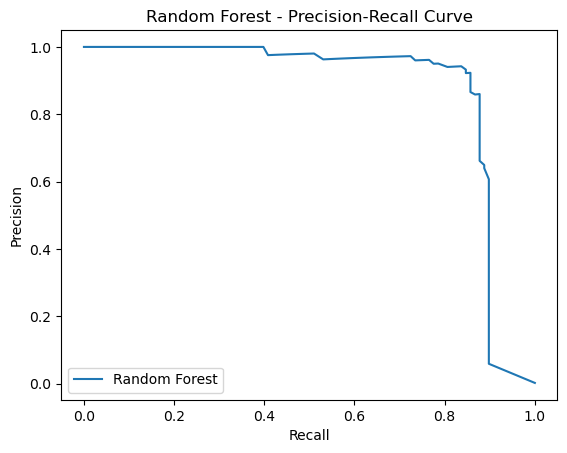

In [12]:
# Logistic Regression results
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")

# Random Forest results
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


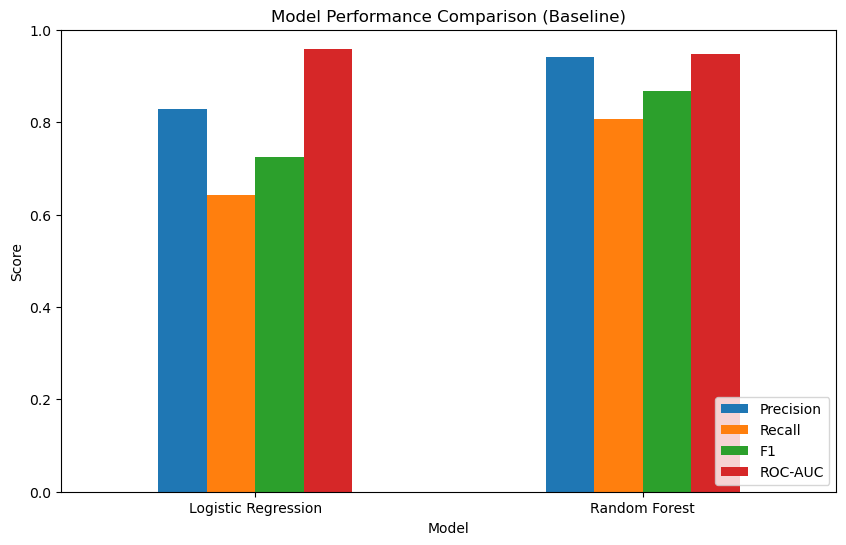

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to store model metrics
def get_metrics(y_true, y_pred, y_prob, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

# Collect results
results = []
results.append(get_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"))
results.append(get_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"))

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
results_df
# Bar chart comparison
metrics = ["Precision", "Recall", "F1", "ROC-AUC"]
results_df.set_index("Model")[metrics].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison (Baseline)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


==== Logistic Regression (Balanced) ====
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0609    0.9184    0.1141        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962

ROC-AUC: 0.9721669425367221


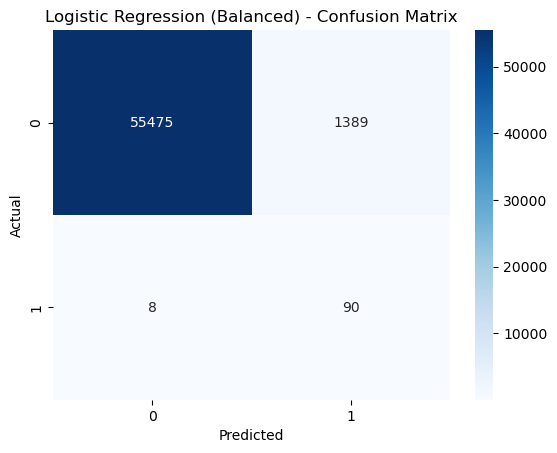

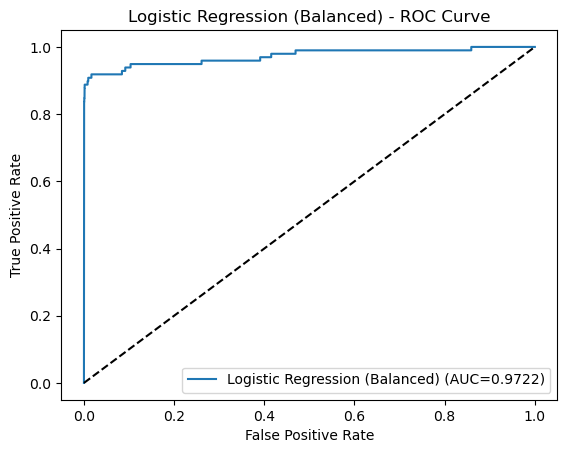

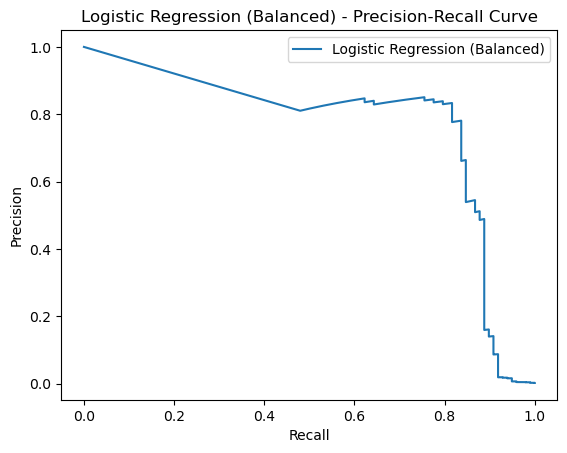

==== Random Forest (Balanced) ====
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9529169310521057


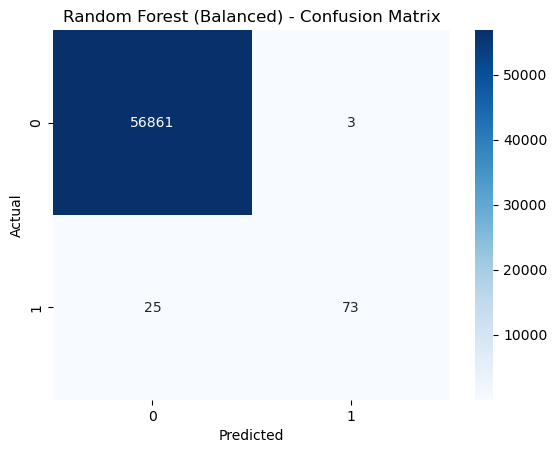

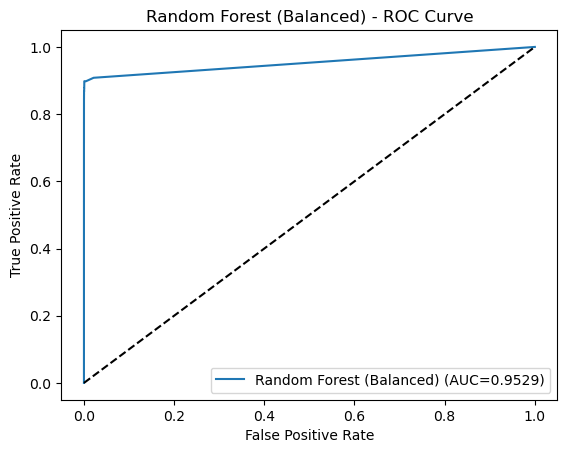

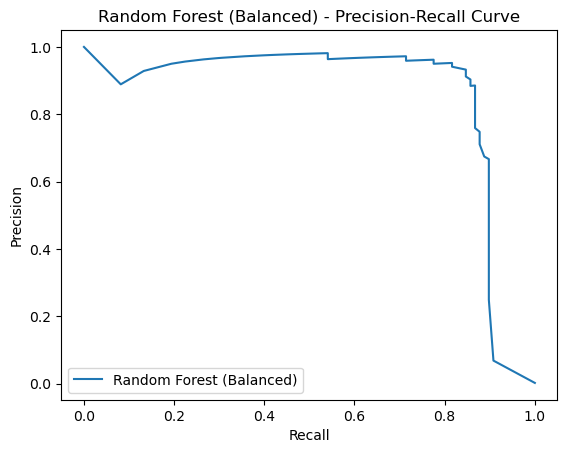

In [14]:
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg_bal.fit(X_train, y_train)
y_pred_lr_bal = log_reg_bal.predict(X_test)
y_prob_lr_bal = log_reg_bal.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_lr_bal, y_prob_lr_bal, "Logistic Regression (Balanced)")
#LR
#############
#RF
rf_bal = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_bal.fit(X_train, y_train)
y_pred_rf_bal = rf_bal.predict(X_test)
y_prob_rf_bal = rf_bal.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_rf_bal, y_prob_rf_bal, "Random Forest (Balanced)")


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    113725
Name: count, dtype: int64
==== Random Forest (SMOTE) ====
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8723    0.8367    0.8542        98

    accuracy                         0.9995     56962
   macro avg     0.9360    0.9183    0.9270     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9678432536492368


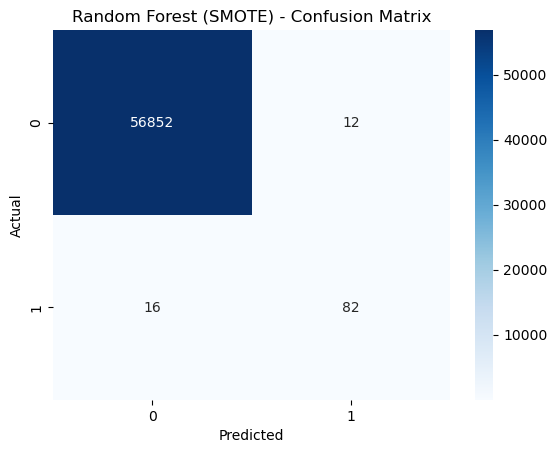

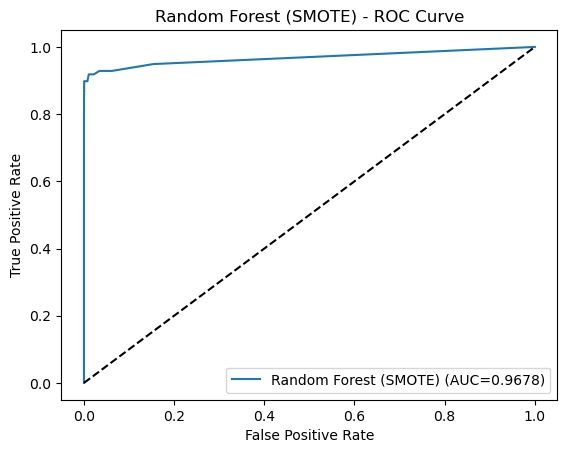

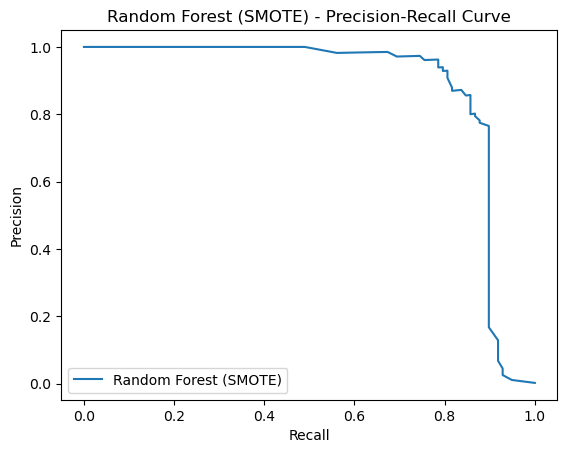

In [15]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training set
sm = SMOTE(random_state=42, sampling_strategy=0.5)  # make frauds = 50% of non-fraud
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

# Train Random Forest on resampled data
rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_sm.predict(X_test)
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_rf_sm, y_prob_rf_sm, "Random Forest (SMOTE)")


Scale Pos Weight: 577.2868020304569
==== XGBoost ====
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8469    0.8469    0.8469        98

    accuracy                         0.9995     56962
   macro avg     0.9233    0.9233    0.9233     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9808398915277985


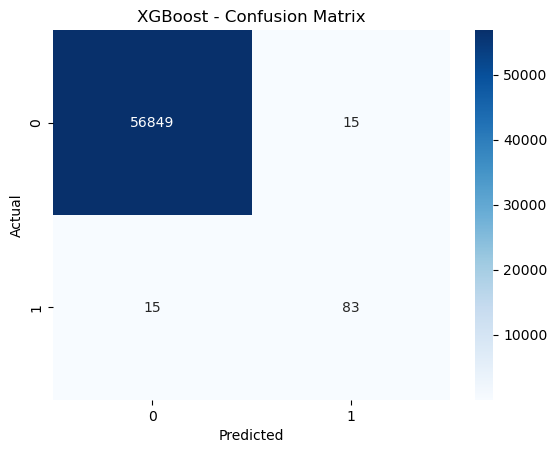

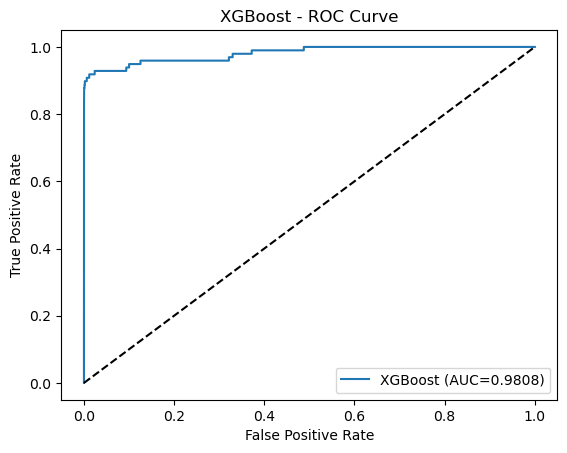

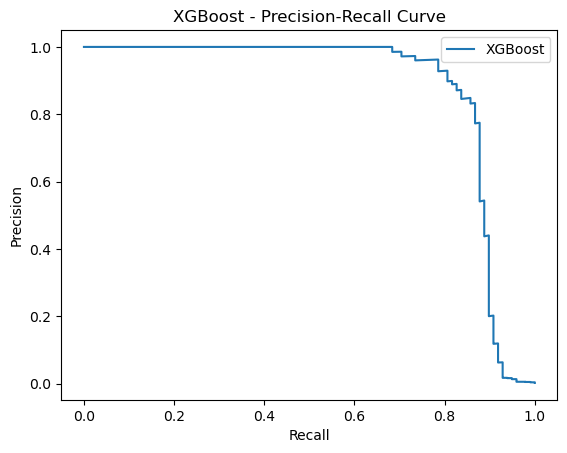

In [16]:
from xgboost import XGBClassifier

# Compute imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale Pos Weight:", scale_pos_weight)

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")


[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stoppe

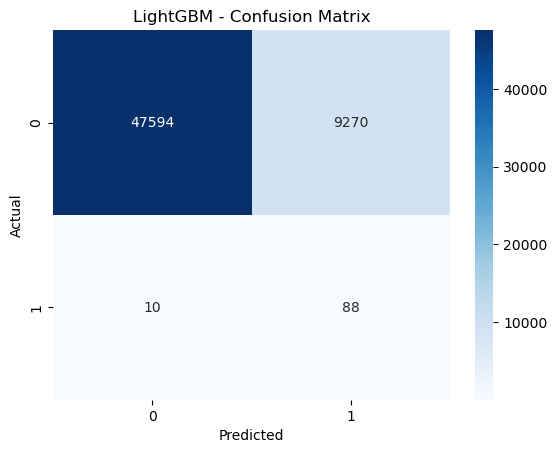

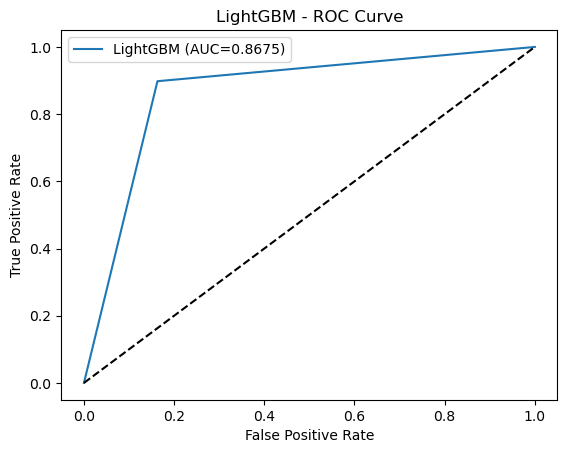

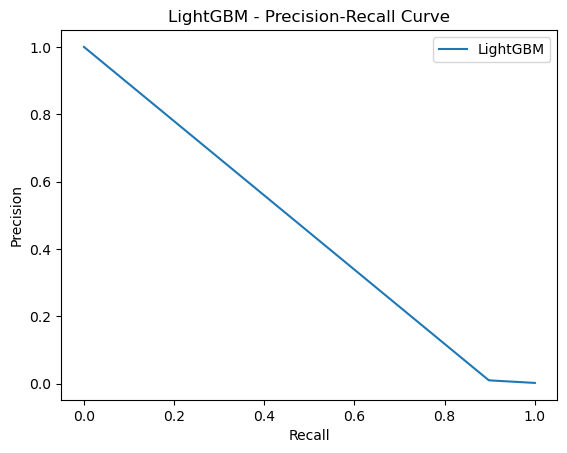

In [17]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_lgb, y_prob_lgb, "LightGBM")


In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Simple feedforward NN
nn = Sequential([
    Dense(32, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # output for binary classification
])

nn.compile(optimizer=Adam(learning_rate=0.001), 
           loss='binary_crossentropy', 
           metrics=['AUC'])


C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = nn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=2
)


Epoch 1/50
90/90 - 2s - 24ms/step - AUC: 0.7709 - loss: 0.7669 - val_AUC: 0.9360 - val_loss: 0.4956
Epoch 2/50
90/90 - 0s - 4ms/step - AUC: 0.9063 - loss: 0.4100 - val_AUC: 0.9564 - val_loss: 0.3627
Epoch 3/50
90/90 - 0s - 4ms/step - AUC: 0.9400 - loss: 0.2997 - val_AUC: 0.9710 - val_loss: 0.2604
Epoch 4/50
90/90 - 0s - 4ms/step - AUC: 0.9560 - loss: 0.2467 - val_AUC: 0.9792 - val_loss: 0.1971
Epoch 5/50
90/90 - 0s - 4ms/step - AUC: 0.9651 - loss: 0.2176 - val_AUC: 0.9846 - val_loss: 0.1644
Epoch 6/50
90/90 - 0s - 4ms/step - AUC: 0.9660 - loss: 0.2057 - val_AUC: 0.9873 - val_loss: 0.1464
Epoch 7/50
90/90 - 0s - 4ms/step - AUC: 0.9726 - loss: 0.1968 - val_AUC: 0.9890 - val_loss: 0.1385
Epoch 8/50
90/90 - 0s - 4ms/step - AUC: 0.9780 - loss: 0.1803 - val_AUC: 0.9900 - val_loss: 0.1281
Epoch 9/50
90/90 - 0s - 5ms/step - AUC: 0.9804 - loss: 0.1685 - val_AUC: 0.9905 - val_loss: 0.1125
Epoch 10/50
90/90 - 0s - 4ms/step - AUC: 0.9740 - loss: 0.1837 - val_AUC: 0.9906 - val_loss: 0.1125
Epoch 11

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step
==== Neural Network ====
              precision    recall  f1-score   support

           0     0.9998    0.9790    0.9893     56864
           1     0.0695    0.9082    0.1291        98

    accuracy                         0.9789     56962
   macro avg     0.5347    0.9436    0.5592     56962
weighted avg     0.9982    0.9789    0.9878     56962

ROC-AUC: 0.9772167642380531


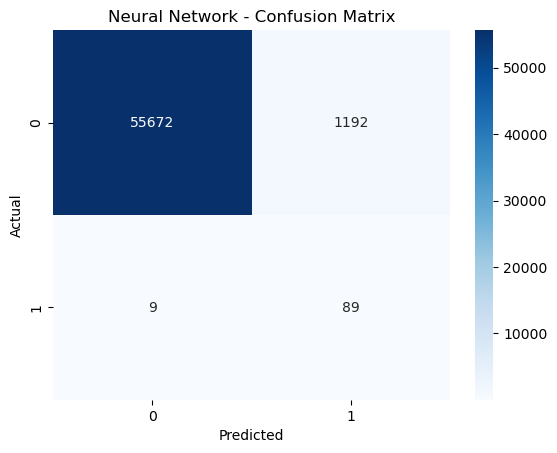

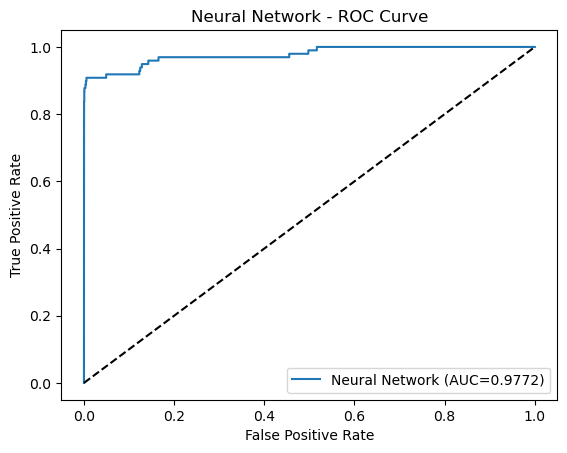

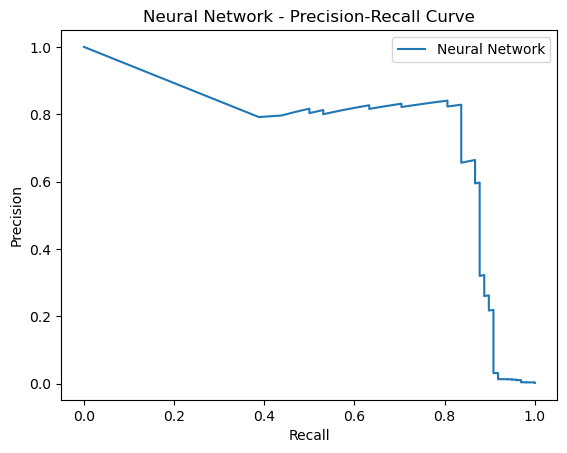

In [21]:
# Predict probabilities
y_prob_nn = nn.predict(X_test).flatten()
# Convert to binary with 0.5 threshold
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# Evaluate
evaluate_model(y_test, y_pred_nn, y_prob_nn, "Neural Network")


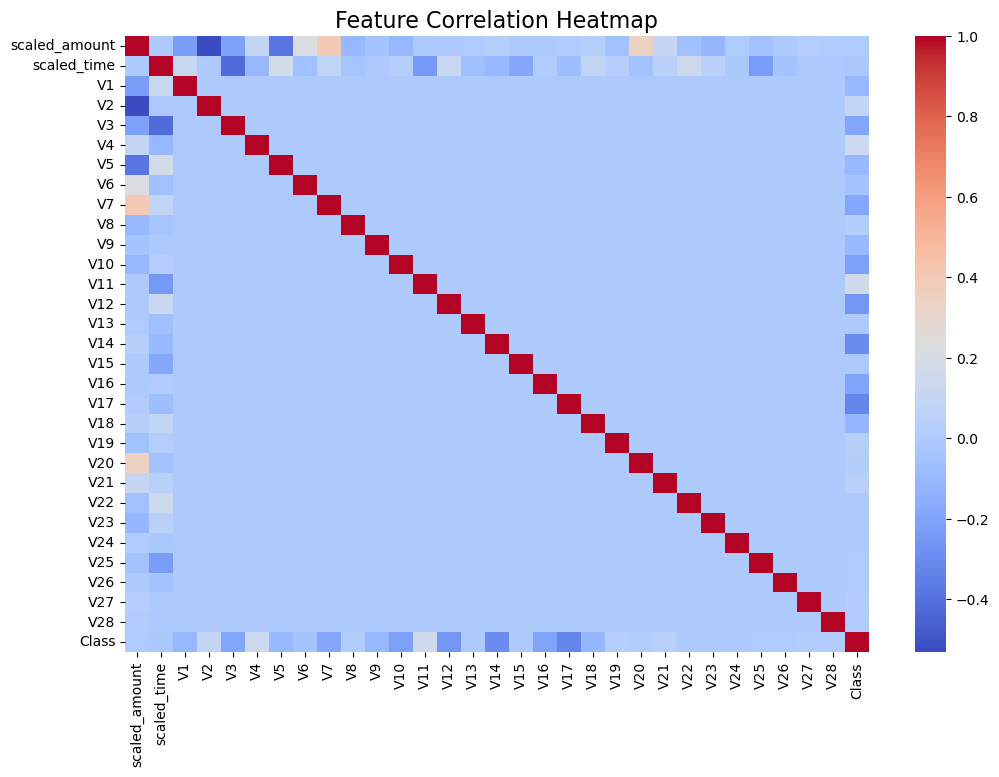

C:\Users\velio\AppData\Local\Temp\ipykernel_36188\3093177613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#4CAF50','#F44336'])


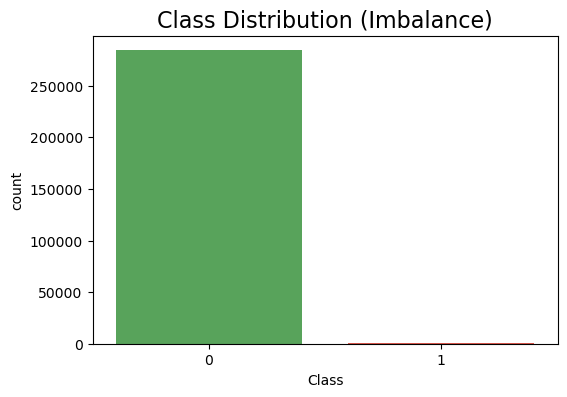

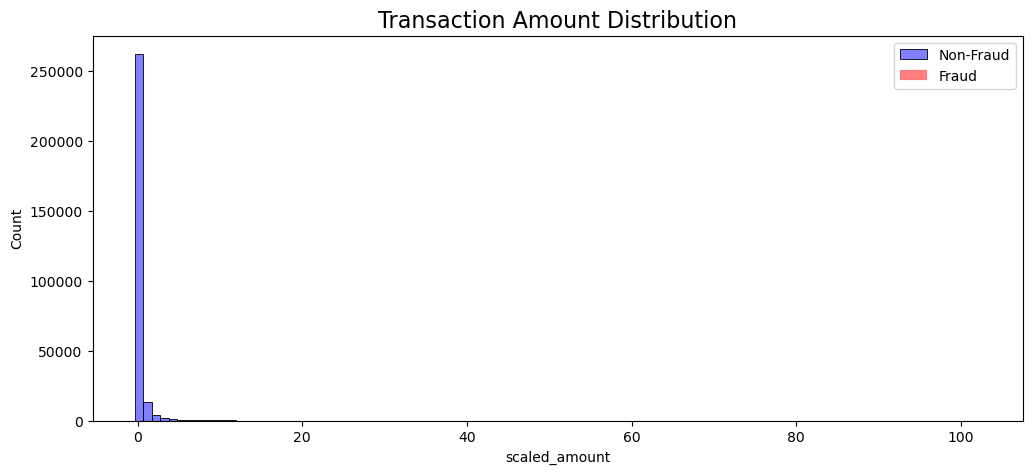

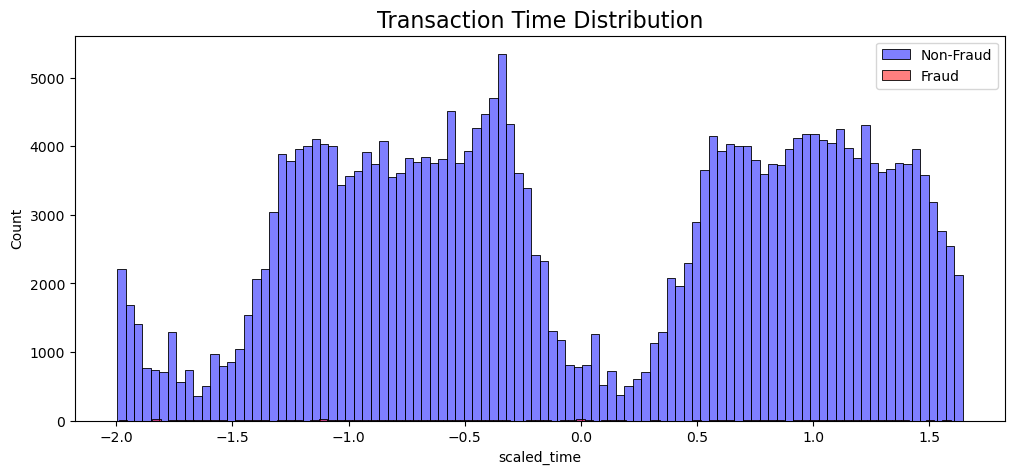

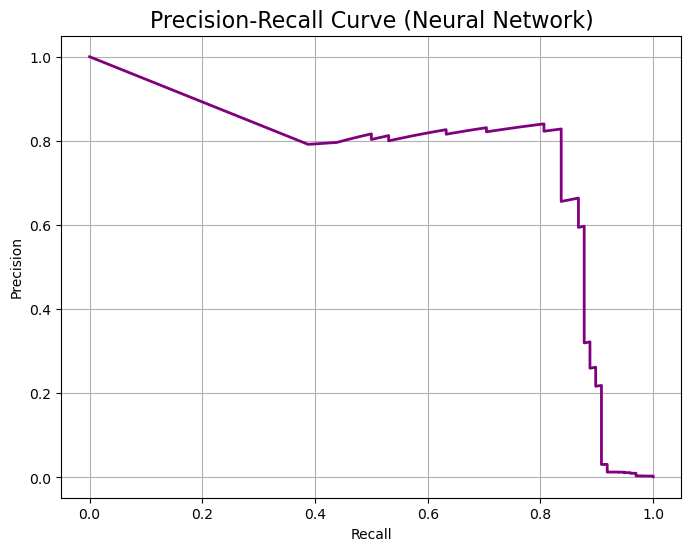

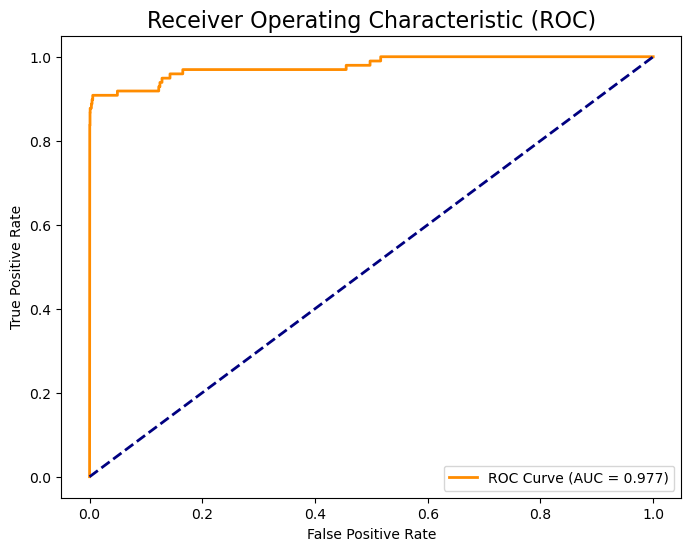

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#4CAF50','#F44336'])
plt.title("Class Distribution (Imbalance)", fontsize=16)
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df[df['Class']==0]['scaled_amount'], bins=100, color='blue', label="Non-Fraud", alpha=0.5)
sns.histplot(df[df['Class']==1]['scaled_amount'], bins=100, color='red', label="Fraud", alpha=0.5)
plt.legend()
plt.title("Transaction Amount Distribution", fontsize=16)
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df[df['Class']==0]['scaled_time'], bins=100, color='blue', label="Non-Fraud", alpha=0.5)
sns.histplot(df[df['Class']==1]['scaled_time'], bins=100, color='red', label="Fraud", alpha=0.5)
plt.legend()
plt.title("Transaction Time Distribution", fontsize=16)
plt.show()

from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_prob_nn)

plt.figure(figsize=(8,6))
plt.plot(rec, prec, color="purple", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Neural Network)", fontsize=16)
plt.grid(True)
plt.show()

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)", fontsize=16)
plt.legend(loc="lower right")
plt.show()


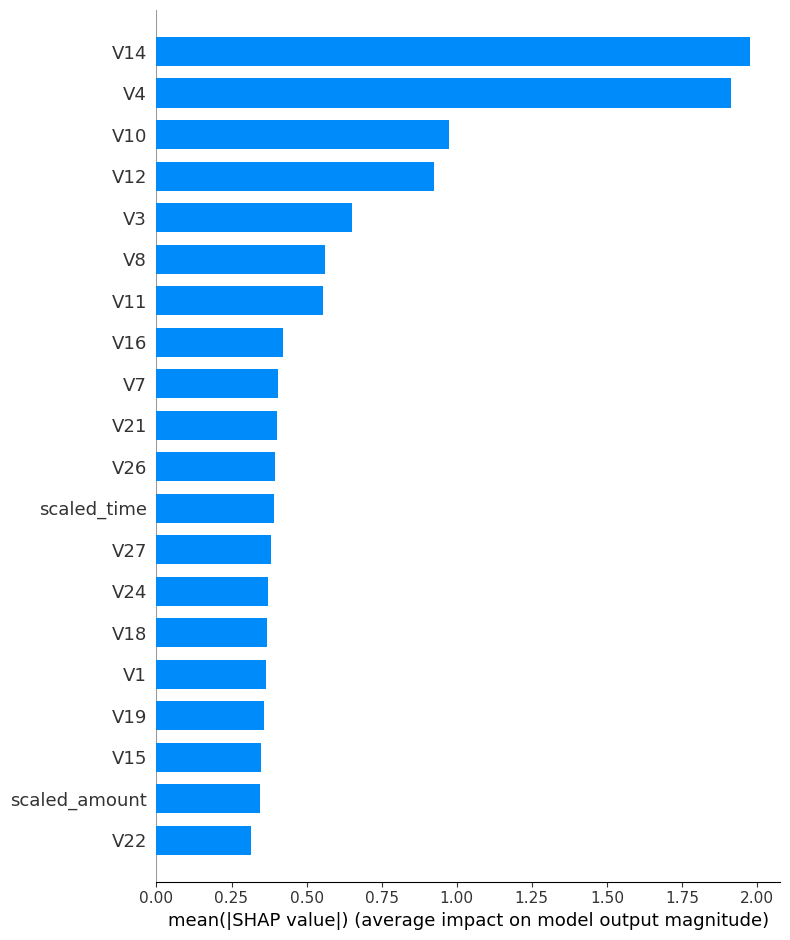

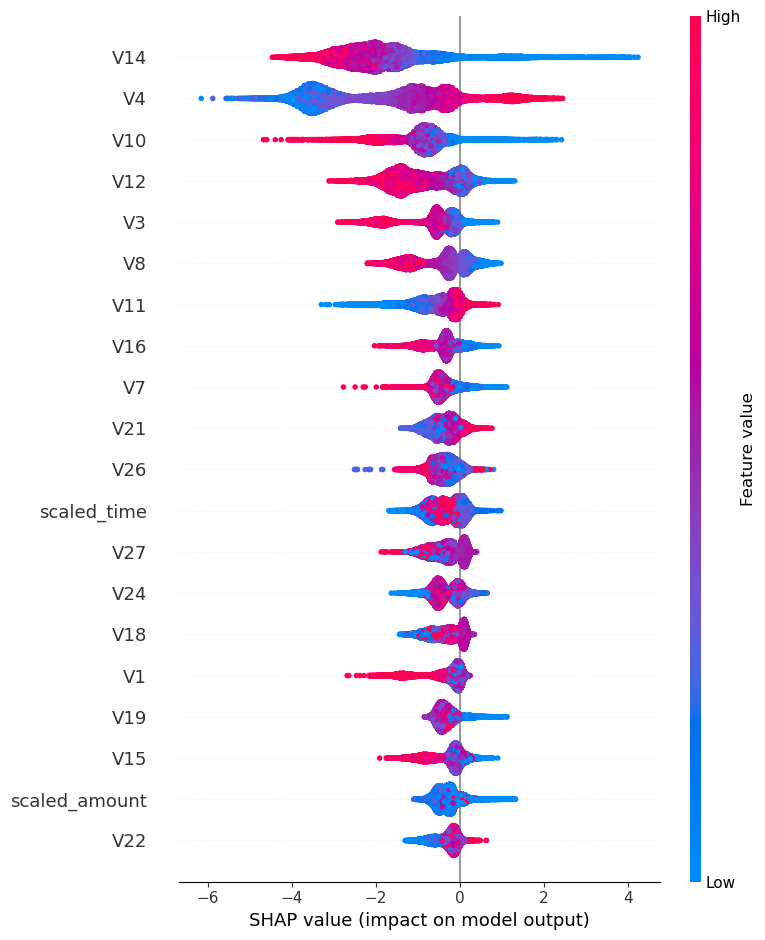

In [25]:
import shap

# Explain XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary Plot (global importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed summary plot (distribution of feature effects)
shap.summary_plot(shap_values, X_test)


In [ ]:
### deepleearning adding more layers now 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

deep_nn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

deep_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)


In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,       # wait 5 epochs before stopping
    restore_best_weights=True
)


In [29]:
# Create validation split from training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

history = deep_nn.fit(
    X_train_sub, y_train_sub,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=2048,
    class_weight=class_weight_dict,  # use computed class weights
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/50
90/90 - 2s - 21ms/step - AUC: 0.8690 - loss: 0.5128 - val_AUC: 0.9492 - val_loss: 0.4262
Epoch 2/50
90/90 - 0s - 4ms/step - AUC: 0.9515 - loss: 0.3101 - val_AUC: 0.9566 - val_loss: 0.2207
Epoch 3/50
90/90 - 0s - 4ms/step - AUC: 0.9525 - loss: 0.2687 - val_AUC: 0.9606 - val_loss: 0.1533
Epoch 4/50
90/90 - 0s - 4ms/step - AUC: 0.9682 - loss: 0.2208 - val_AUC: 0.9607 - val_loss: 0.1271
Epoch 5/50
90/90 - 0s - 4ms/step - AUC: 0.9716 - loss: 0.2060 - val_AUC: 0.9633 - val_loss: 0.1153
Epoch 6/50
90/90 - 0s - 4ms/step - AUC: 0.9822 - loss: 0.1731 - val_AUC: 0.9620 - val_loss: 0.1072
Epoch 7/50
90/90 - 0s - 4ms/step - AUC: 0.9810 - loss: 0.1709 - val_AUC: 0.9626 - val_loss: 0.0913
Epoch 8/50
90/90 - 0s - 4ms/step - AUC: 0.9814 - loss: 0.1604 - val_AUC: 0.9626 - val_loss: 0.0861
Epoch 9/50
90/90 - 0s - 4ms/step - AUC: 0.9858 - loss: 0.1500 - val_AUC: 0.9644 - val_loss: 0.0799
Epoch 10/50
90/90 - 0s - 4ms/step - AUC: 0.9883 - loss: 0.1379 - val_AUC: 0.9641 - val_loss: 0.0760
Epoch 11

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step
==== Deep Neural Network ====
              precision    recall  f1-score   support

           0     0.9998    0.9807    0.9902     56864
           1     0.0743    0.8980    0.1372        98

    accuracy                         0.9806     56962
   macro avg     0.5370    0.9393    0.5637     56962
weighted avg     0.9982    0.9806    0.9887     56962

ROC-AUC: 0.9759221429145659


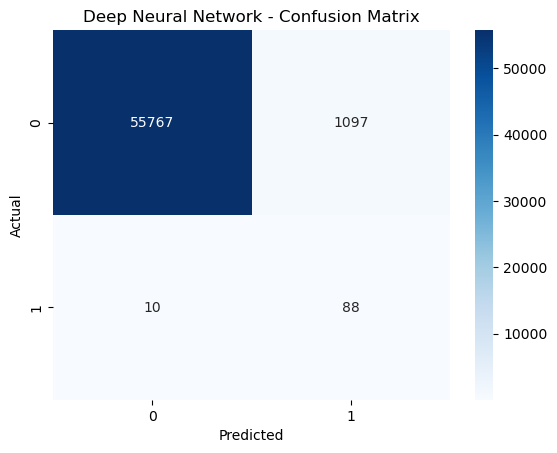

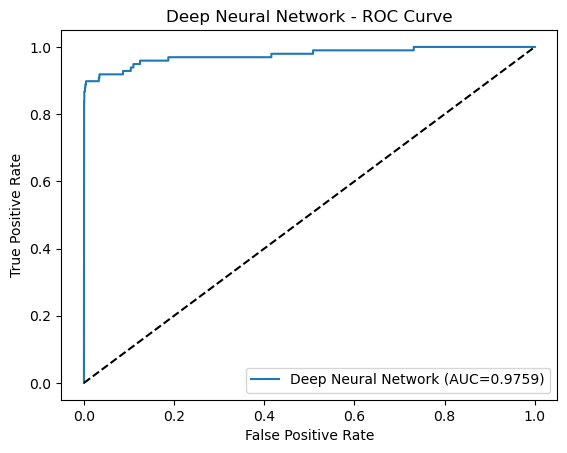

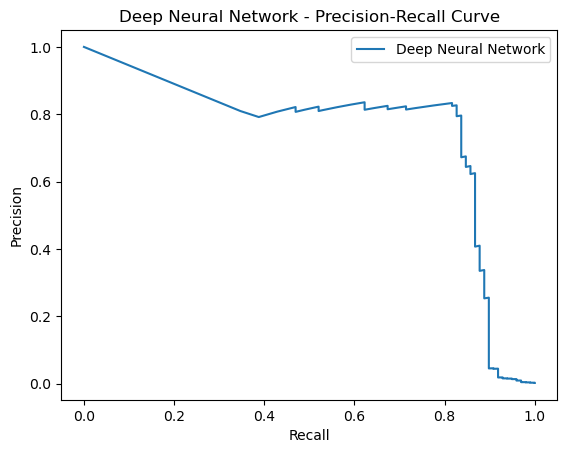

In [30]:
y_prob_deep = deep_nn.predict(X_test).flatten()
y_pred_deep = (y_prob_deep > 0.5).astype(int)

evaluate_model(y_test, y_pred_deep, y_prob_deep, "Deep Neural Network")


In [31]:
history = deep_nn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=2048,
    class_weight={0:1, 1:577},  # imbalance handling
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/50
112/112 - 0s - 4ms/step - AUC: 0.9886 - loss: 0.2430 - val_AUC: 0.9722 - val_loss: 0.0443
Epoch 2/50
112/112 - 1s - 5ms/step - AUC: 0.9881 - loss: 0.2695 - val_AUC: 0.9781 - val_loss: 0.0478
Epoch 3/50
112/112 - 0s - 4ms/step - AUC: 0.9920 - loss: 0.2061 - val_AUC: 0.9916 - val_loss: 0.0490
Epoch 4/50
112/112 - 0s - 4ms/step - AUC: 0.9921 - loss: 0.2113 - val_AUC: 0.9934 - val_loss: 0.0470
Epoch 5/50
112/112 - 0s - 4ms/step - AUC: 0.9955 - loss: 0.1725 - val_AUC: 0.9945 - val_loss: 0.0423


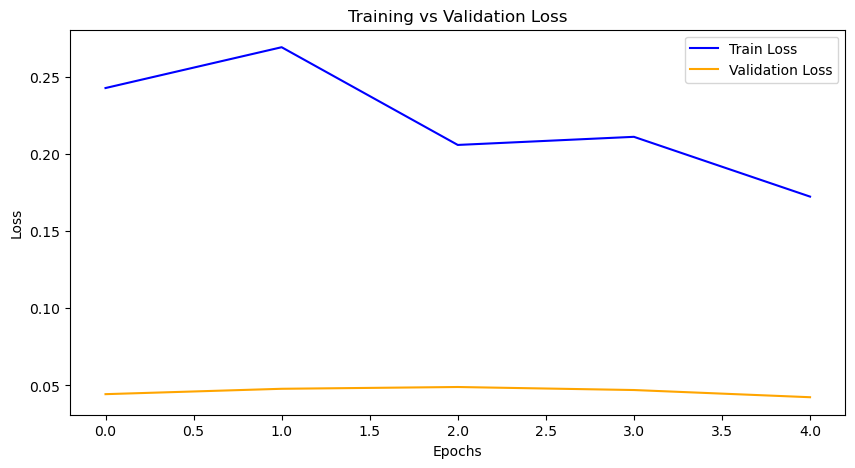

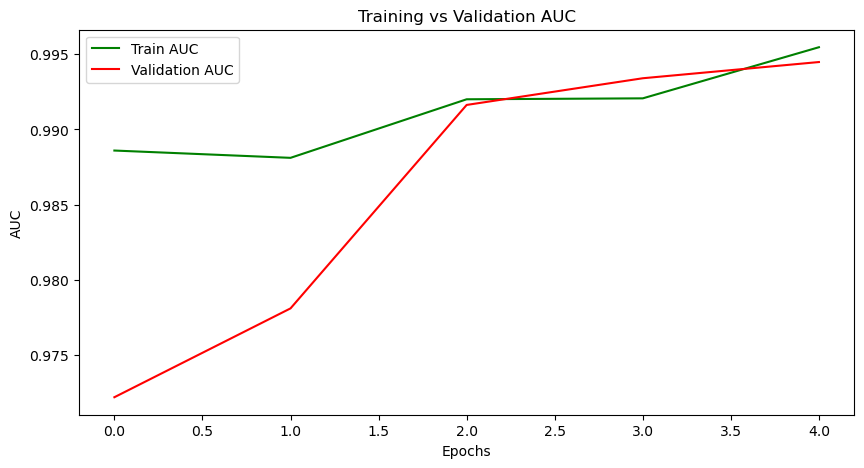

In [33]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot AUC
plt.figure(figsize=(10,5))
plt.plot(history.history['AUC'], label='Train AUC', color='green')
plt.plot(history.history['val_AUC'], label='Validation AUC', color='red')
plt.title('Training vs Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.show()


In [ ]:
### gonna create larger mlp now

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

mlp = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)


In [35]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== Fold {fold+1} =====")
    
    # Split data
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Define model fresh for each fold
    model = Sequential([
        Input(shape=(X_train_fold.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['AUC'])
    
    # Train
    model.fit(X_train_fold, y_train_fold,
              validation_data=(X_val_fold, y_val_fold),
              epochs=20,
              batch_size=2048,
              class_weight={0:1, 1:577},
              verbose=0)
    
    # Evaluate
    score = model.evaluate(X_val_fold, y_val_fold, verbose=0)[1]  # AUC
    print(f"Fold {fold+1} AUC: {score:.4f}")
    auc_scores.append(score)

print("\nAverage AUC across folds:", np.mean(auc_scores))



===== Fold 1 =====
Fold 1 AUC: 0.9817

===== Fold 2 =====
Fold 2 AUC: 0.9810

===== Fold 3 =====
Fold 3 AUC: 0.9860

===== Fold 4 =====
Fold 4 AUC: 0.9802

===== Fold 5 =====
Fold 5 AUC: 0.9840

Average AUC across folds: 0.982575523853302


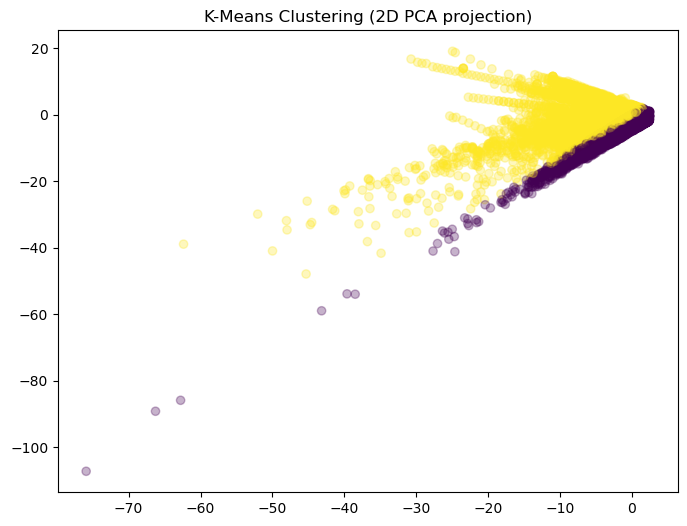

In [36]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

# Plot clusters vs actual fraud labels
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters, cmap='viridis', alpha=0.3)
plt.title("K-Means Clustering (2D PCA projection)")
plt.show()


In [37]:
import time
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import load_model

results = []

# Helper function
def evaluate_and_store(model_name, model, X_train, y_train, X_test, y_test, 
                       is_nn=False, class_weight=None, save=True):
    start = time.time()
    
    if is_nn:  # Neural Network
        model.fit(X_train, y_train,
                  validation_data=(X_test, y_test),
                  epochs=20,
                  batch_size=2048,
                  verbose=0,
                  class_weight=class_weight)
        train_time = time.time() - start
        
        y_prob = model.predict(X_test).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        
        # Save NN
        if save:
            model.save(f"{model_name}.h5")
            
    else:  # Sklearn/XGB/LGBM
        model.fit(X_train, y_train)
        train_time = time.time() - start
        
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
        
        # Save ML model
        if save:
            joblib.dump(model, f"{model_name}.pkl")
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4),
        "Train Time (s)": round(train_time, 2)
    })


# ===============================
# Models
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Logistic Regression
evaluate_and_store("Logistic_Regression",
                   LogisticRegression(max_iter=500, class_weight="balanced"),
                   X_train, y_train, X_test, y_test)

# Decision Tree
evaluate_and_store("Decision_Tree",
                   DecisionTreeClassifier(class_weight="balanced", max_depth=10),
                   X_train, y_train, X_test, y_test)

# Random Forest
evaluate_and_store("Random_Forest",
                   RandomForestClassifier(n_estimators=200, class_weight="balanced"),
                   X_train, y_train, X_test, y_test)

# XGBoost
evaluate_and_store("XGBoost",
                   xgb.XGBClassifier(use_label_encoder=False,
                                     eval_metric="logloss",
                                     scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])),
                   X_train, y_train, X_test, y_test)

# LightGBM
evaluate_and_store("LightGBM",
                   lgb.LGBMClassifier(scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])),
                   X_train, y_train, X_test, y_test)

# Simple Neural Network
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])

evaluate_and_store("Neural_Network",
                   nn, X_train, y_train, X_test, y_test,
                   is_nn=True,
                   class_weight={0:1, 1:len(y_train[y_train==0])/len(y_train[y_train==1])})

# ===============================
# Results
# ===============================
df_results = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(df_results.sort_values(by="Recall", ascending=False))


C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [20:39:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 404us/step



=== Model Comparison ===
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
0  Logistic_Regression    0.9755     0.0609  0.9184    0.1141   0.9722   
5       Neural_Network    0.9798     0.0725  0.9082    0.1342   0.9814   
4             LightGBM    0.8154     0.0080  0.8673    0.0159   0.8413   
3              XGBoost    0.9996     0.8925  0.8469    0.8691   0.9652   
1        Decision_Tree    0.9907     0.1321  0.7857    0.2261   0.8915   
2        Random_Forest    0.9995     0.9615  0.7653    0.8523   0.9572   

   Train Time (s)  
0            0.86  
5            6.20  
4            0.54  
3            0.88  
1            7.45  
2          298.93  


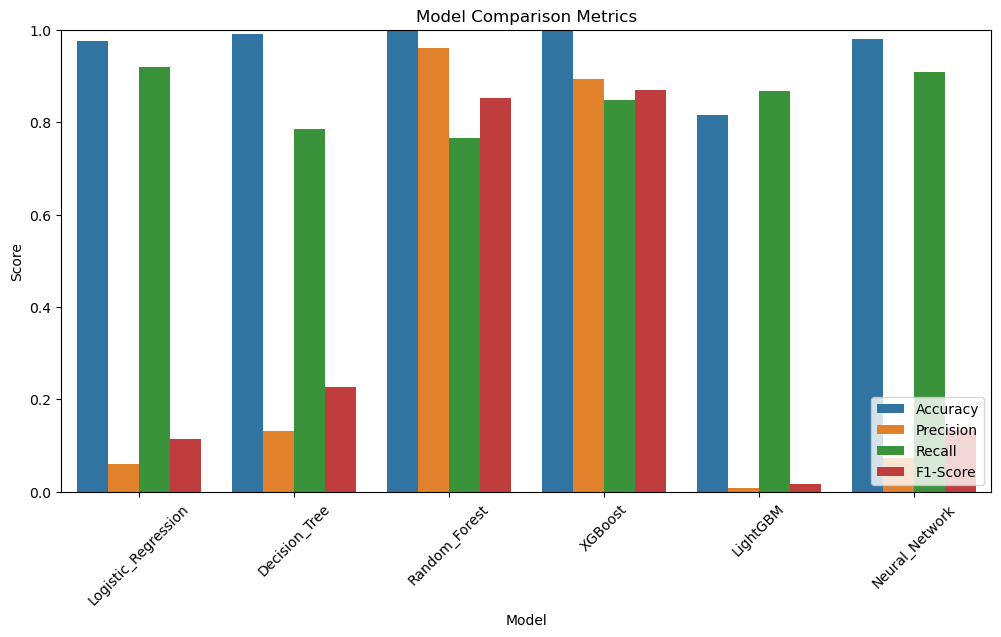

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
df_melt = df_results.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Metrics")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


Processing Logistic Regression...
Processing Decision Tree...
Processing Random Forest...
Processing XGBoost...
Processing LightGBM...
Processing Neural Network...
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 434us/step


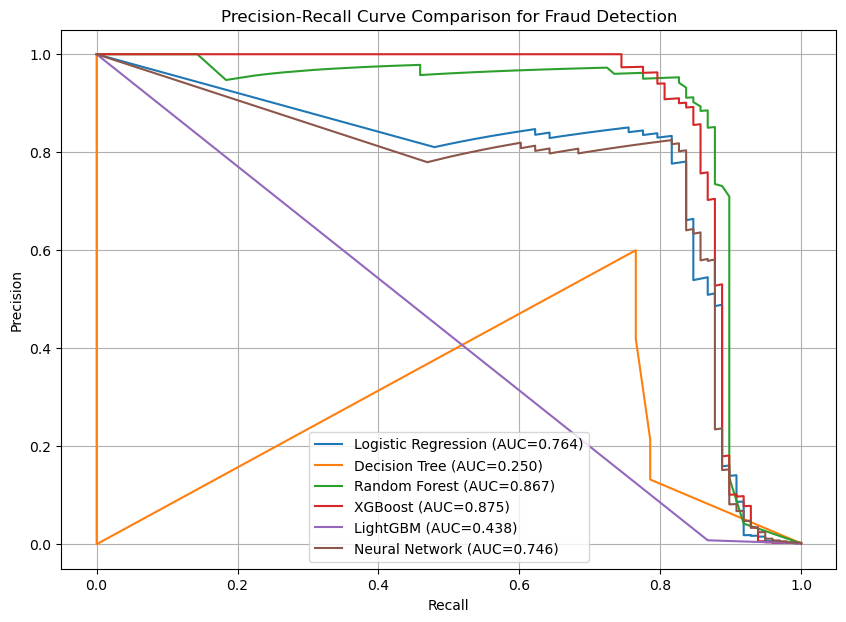

In [46]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model

plt.figure(figsize=(10,7))

# Load saved models
models_to_plot = {
    "Logistic Regression": joblib.load("Logistic_Regression.pkl"),
    "Decision Tree": joblib.load("Decision_Tree.pkl"),
    "Random Forest": joblib.load("Random_Forest.pkl"),
    "XGBoost": joblib.load("XGBoost.pkl"),
    "LightGBM": joblib.load("LightGBM.pkl"),
    "Neural Network": load_model("Neural_Network.h5")
}

# Predict and plot
for name, model in models_to_plot.items():
    print(f"Processing {name}...")
    
    if name == "Neural Network":
        y_prob = model.predict(X_test).flatten()
    else:
        y_prob = model.predict_proba(X_test)[:,1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison for Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
### tryin stratifield k fold cross validation now to compare with 5 fold 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
import joblib
import numpy as np
import pandas as pd

# -----------------------------
# Models to cross-validate (sklearn only)
# -----------------------------
cv_models = {
    "Logistic Regression": joblib.load("Logistic_Regression.pkl"),
    "Decision Tree": joblib.load("Decision_Tree.pkl"),
    "Random Forest": joblib.load("Random_Forest.pkl"),
    "XGBoost": joblib.load("XGBoost.pkl"),
    "LightGBM": joblib.load("LightGBM.pkl"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Prepare dataframe to store CV results
cv_metrics_list = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
cv_results = pd.DataFrame(columns=["Model"] + cv_metrics_list)

# 3-Fold Stratified CV
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in cv_models.items():
    acc_list, prec_list, rec_list, f1_list, roc_list = [], [], [], [], []
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Fit model
        model.fit(X_tr, y_tr)
        
        # Predict
        y_pred = model.predict(X_val)
        if name == "KNN":
            y_prob = y_pred  # approximate for ROC
        else:
            y_prob = model.predict_proba(X_val)[:,1]
        
        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        prec_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred, zero_division=0))
        f1_list.append(f1_score(y_val, y_pred, zero_division=0))
        roc_list.append(roc_auc_score(y_val, y_prob))
    
    # Save mean metrics for this model
    cv_results = pd.concat([cv_results, pd.DataFrame([{
        "Model": name,
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1-Score": np.mean(f1_list),
        "ROC-AUC": np.mean(roc_list)
    }])], ignore_index=True)

# Show 3-Fold CV metrics
print("=== 3-Fold Cross-Validation Metrics ===")
print(cv_results)


C:\Users\velio\AppData\Local\Temp\ipykernel_36188\3519877245.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cv_results = pd.concat([cv_results, pd.DataFrame([{
C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [21:07:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [21:07:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\velio\AppData\Roaming\P

[LightGBM] [Info] Number of positive: 262, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 151896, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001725 -> initscore=-6.360880
[LightGBM] [Info] Start training from score -6.360880
[LightGBM] [Info] Number of positive: 263, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 151897, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001731 -> initscore=-6.357071
[LightGBM] [Info] Start training from score -6.357071
[LightGBM] [

In [53]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

# Models to cross-validate (sklearn only)
cv_models = {
    "Logistic Regression": joblib.load("Logistic_Regression.pkl"),
    "Decision Tree": joblib.load("Decision_Tree.pkl"),
    "Random Forest": joblib.load("Random_Forest.pkl"),
    "XGBoost": joblib.load("XGBoost.pkl"),
    "LightGBM": joblib.load("LightGBM.pkl"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Prepare dataframe to store 5-Fold CV results
cv_5fold_results = pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1-Score","ROC-AUC"])

# 5-Fold Stratified CV
kf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in cv_models.items():
    acc_list, prec_list, rec_list, f1_list, roc_list = [], [], [], [], []
    
    for train_idx, val_idx in kf5.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Fit model
        model.fit(X_tr, y_tr)
        
        # Predict
        y_pred = model.predict(X_val)
        if name == "KNN":
            y_prob = y_pred  # approximate for ROC
        else:
            y_prob = model.predict_proba(X_val)[:,1]
        
        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        prec_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred, zero_division=0))
        f1_list.append(f1_score(y_val, y_pred, zero_division=0))
        roc_list.append(roc_auc_score(y_val, y_prob))
    
    # Save mean metrics for this model
    cv_5fold_results = pd.concat([cv_5fold_results, pd.DataFrame([{
        "Model": name,
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1-Score": np.mean(f1_list),
        "ROC-AUC": np.mean(roc_list)
    }])], ignore_index=True)

# Save 5-Fold CV results
joblib.dump(cv_5fold_results, "cv_5fold_results.pkl")

# Show 5-Fold CV metrics
print("=== 5-Fold Cross-Validation Metrics ===")
print(cv_5fold_results)


C:\Users\velio\AppData\Local\Temp\ipykernel_36188\1635909987.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cv_5fold_results = pd.concat([cv_5fold_results, pd.DataFrame([{
C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [21:32:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\velio\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [21:32:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\velio\AppDa

[LightGBM] [Info] Number of positive: 316, number of negative: 181960
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001734 -> initscore=-6.355800
[LightGBM] [Info] Start training from score -6.355800
[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007667 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001728 -> initscore=-6.358975
[LightGBM] [Info] Start training from score -6.358975
[LightGBM] [

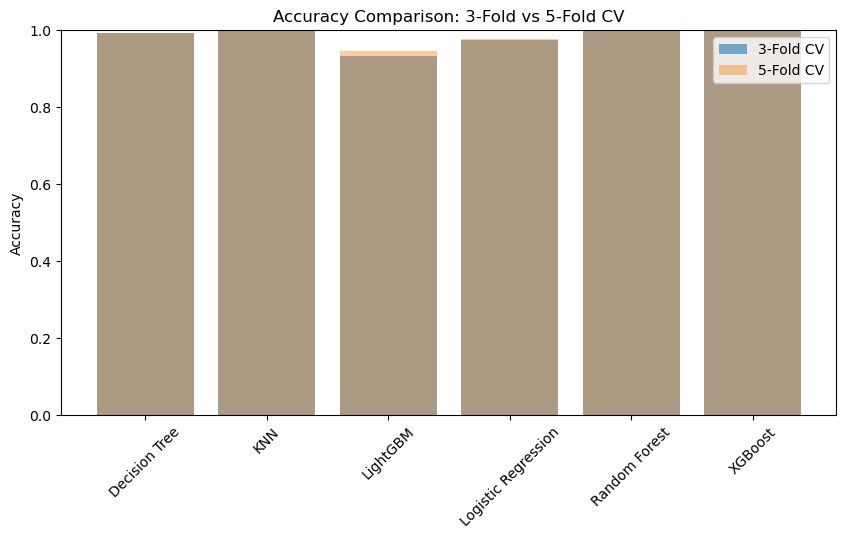

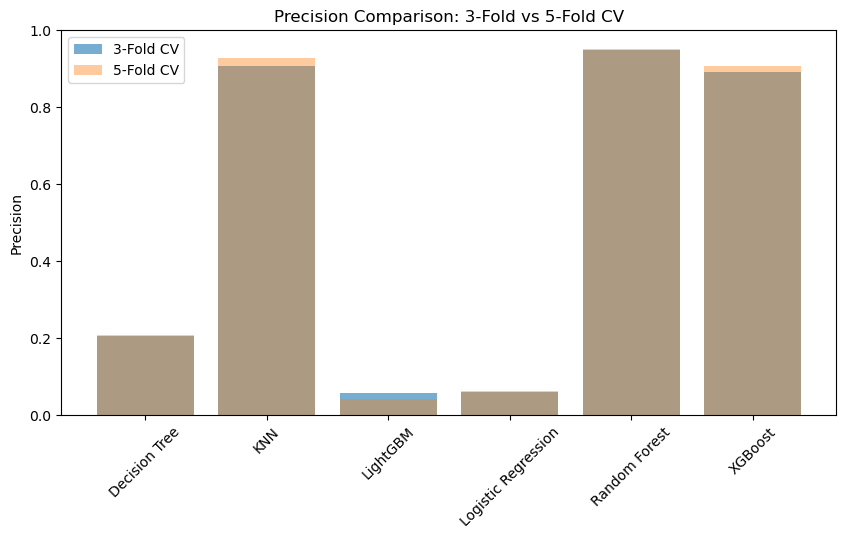

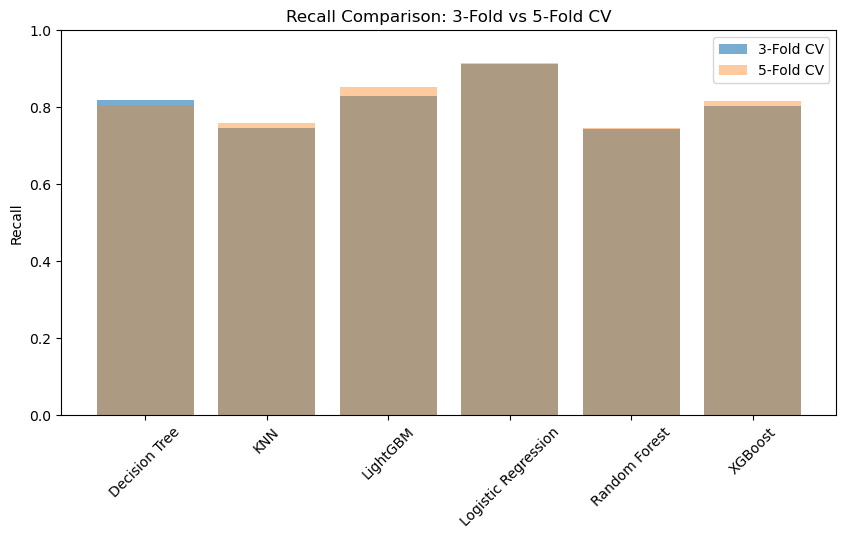

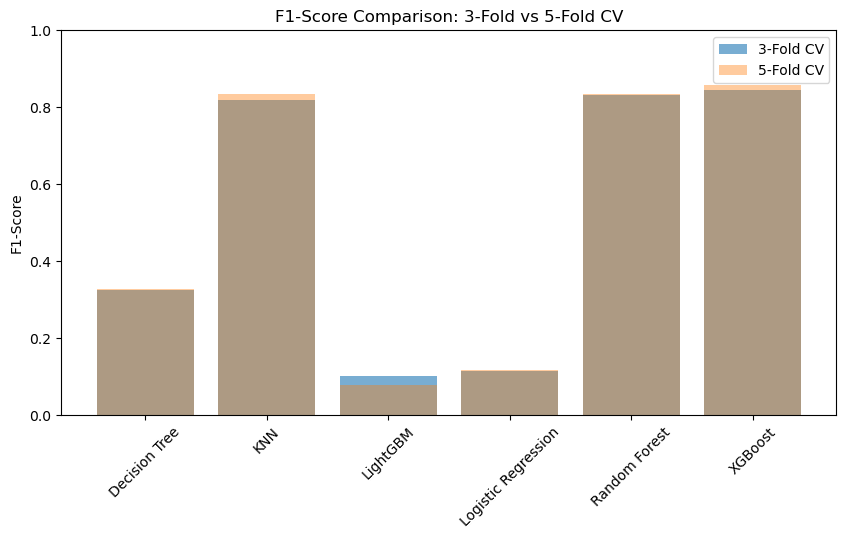

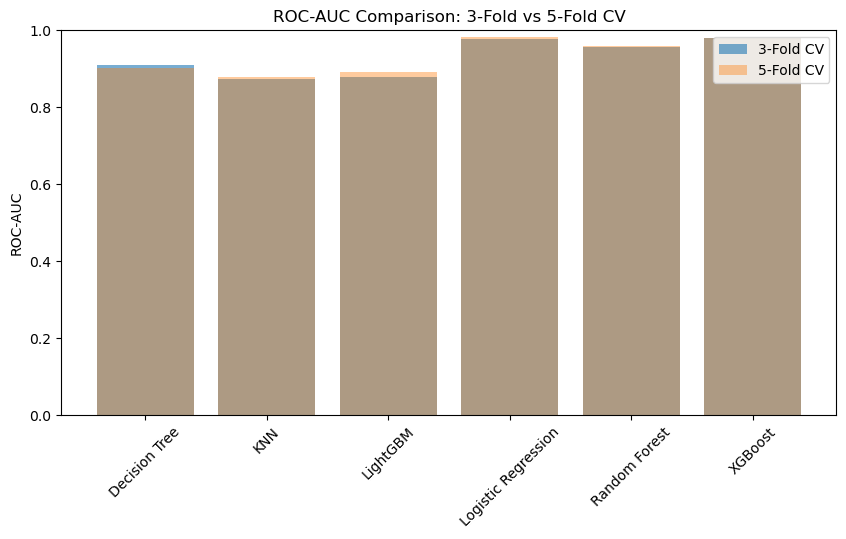

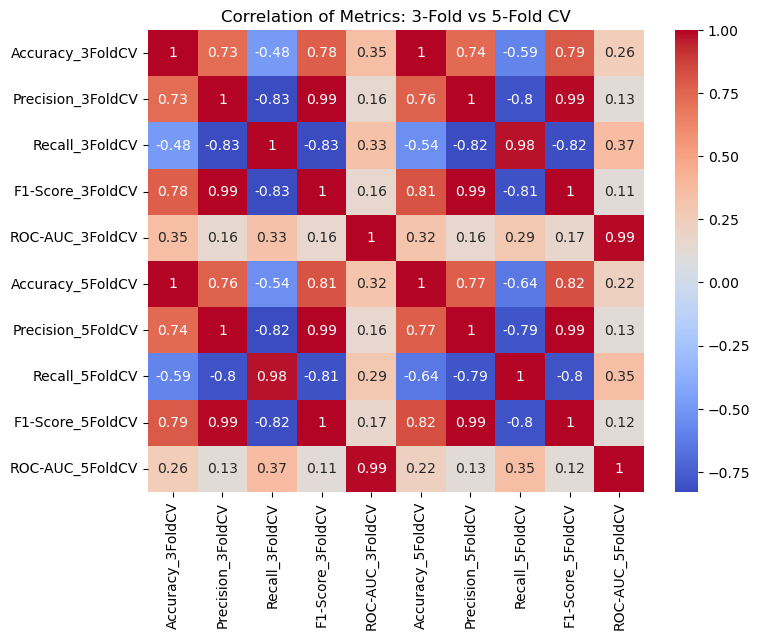

=== 3-Fold vs 5-Fold CV Metrics Comparison ===
                 Model  Accuracy_3FoldCV  Precision_3FoldCV  Recall_3FoldCV  \
0        Decision Tree          0.994057           0.204636        0.819743   
1                  KNN          0.999429           0.907430        0.746183   
2             LightGBM          0.934297           0.056775        0.829921   
3  Logistic Regression          0.975396           0.060684        0.911154   
4        Random Forest          0.999486           0.948312        0.743697   
5              XGBoost          0.999486           0.891471        0.802086   

   F1-Score_3FoldCV  ROC-AUC_3FoldCV  Accuracy_5FoldCV  Precision_5FoldCV  \
0          0.326591         0.908918          0.993904           0.209289   
1          0.818931         0.873026          0.999478           0.926899   
2          0.101937         0.879535          0.946490           0.042160   
3          0.113768         0.976479          0.976190           0.062871   
4          0.8

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge 3-Fold and 5-Fold CV metrics
cv_comparison = cv_results.merge(cv_5fold_results, on="Model", how="outer", suffixes=("_3FoldCV","_5FoldCV"))

# Bar chart: 3-Fold vs 5-Fold CV
metrics_to_plot = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,5))
    plt.bar(cv_comparison['Model'], cv_comparison[f"{metric}_3FoldCV"], alpha=0.6, label="3-Fold CV")
    plt.bar(cv_comparison['Model'], cv_comparison[f"{metric}_5FoldCV"], alpha=0.4, label="5-Fold CV")
    plt.title(f"{metric} Comparison: 3-Fold vs 5-Fold CV")
    plt.ylabel(metric)
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.show()

# Heatmap of correlations
all_metric_cols = [f"{m}_3FoldCV" for m in metrics_to_plot] + [f"{m}_5FoldCV" for m in metrics_to_plot]
plt.figure(figsize=(8,6))
sns.heatmap(cv_comparison[all_metric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Metrics: 3-Fold vs 5-Fold CV")
plt.show()

# Show comparison table
print("=== 3-Fold vs 5-Fold CV Metrics Comparison ===")
print(cv_comparison)


C:\Users\velio\AppData\Local\Temp\ipykernel_36188\554057148.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 431us/step


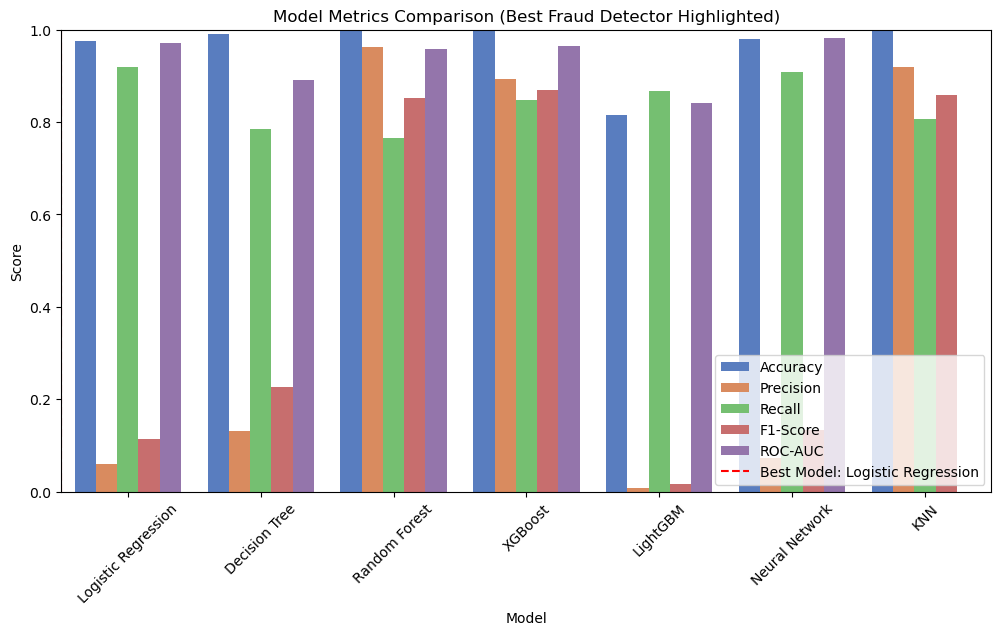

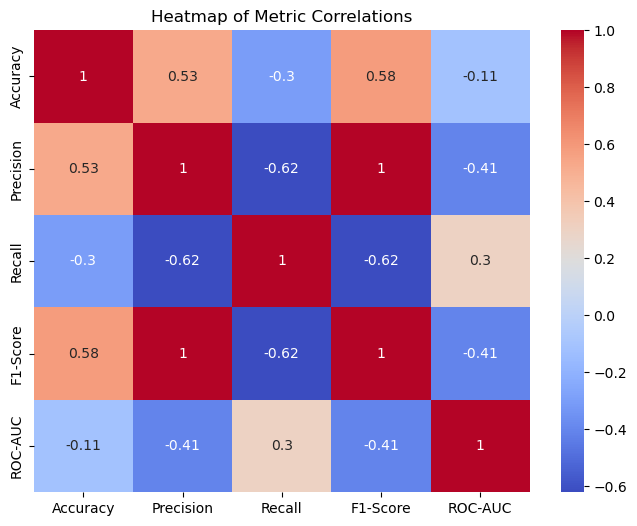

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 399us/step


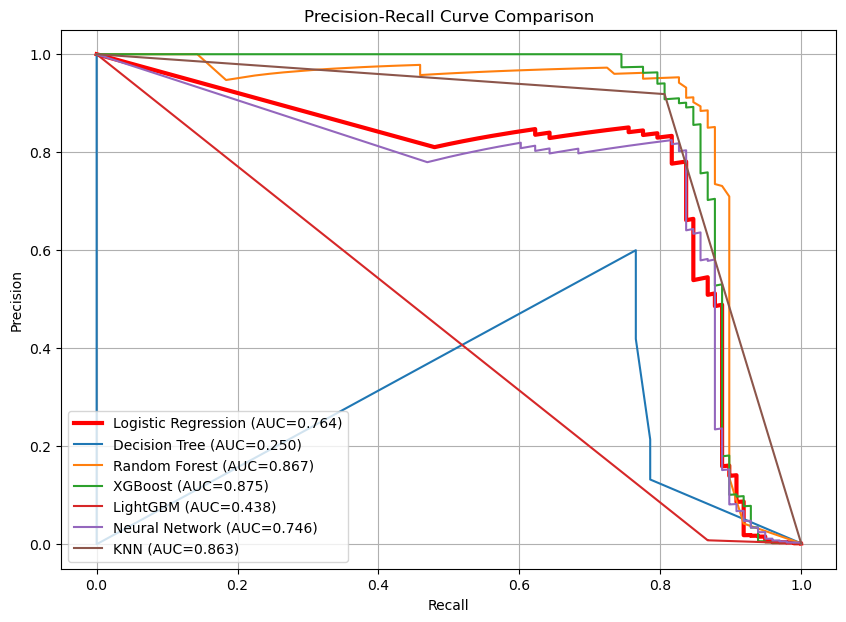

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.975475   0.060852  0.918367  0.114141  0.972167
5       Neural Network  0.979846   0.072476  0.908163  0.134238  0.981438
4             LightGBM  0.815351   0.008026  0.867347  0.015906  0.841306
3              XGBoost  0.999561   0.892473  0.846939  0.869110  0.965221
6                  KNN  0.999544   0.918605  0.806122  0.858696  0.000000
1        Decision Tree  0.990748   0.132075  0.785714  0.226138  0.891491
2        Random Forest  0.999544   0.961538  0.765306  0.852273  0.957205

Best Fraud Detector: Logistic Regression with Recall = 0.918


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import load_model

# -----------------------------
# Load saved models
# -----------------------------
models = {
    "Logistic Regression": joblib.load("Logistic_Regression.pkl"),
    "Decision Tree": joblib.load("Decision_Tree.pkl"),
    "Random Forest": joblib.load("Random_Forest.pkl"),
    "XGBoost": joblib.load("XGBoost.pkl"),
    "LightGBM": joblib.load("LightGBM.pkl"),
    "Neural Network": load_model("Neural_Network.h5")
}

# Recompile NN to remove warning
models["Neural Network"].compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])

# Add KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
models["KNN"] = knn

# -----------------------------
# Metrics calculation
# -----------------------------
metrics_list = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
metrics_df = pd.DataFrame(columns=["Model"] + metrics_list)

best_model = None
best_recall = 0

for name, model in models.items():
    # Predict
    if name == "Neural Network":
        y_prob = model.predict(X_test).flatten()
        y_pred = (y_prob > 0.5).astype(int)
    elif name == "KNN":
        y_pred = model.predict(X_test)
        y_prob = y_pred  # approximate for PR curve
    else:
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if name != "KNN" else 0
    
    # Append row using concat (pandas 2.0+)
    new_row = pd.DataFrame([{
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc
    }])
    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
    
    # Track best model by Recall (fraud detection priority)
    if rec > best_recall:
        best_recall = rec
        best_model = name

# -----------------------------
# Bar chart: highlight best model
# -----------------------------
plt.figure(figsize=(12,6))
metrics_melted = metrics_df.melt(id_vars="Model", value_vars=metrics_list, var_name="Metric", value_name="Score")
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric", palette="muted")
plt.xticks(rotation=45)

# Highlight best model
best_idx = metrics_df.index[metrics_df['Model']==best_model][0]
plt.axvline(best_idx-0.5, color='red', linestyle='--', label=f'Best Model: {best_model}')
plt.title("Model Metrics Comparison (Best Fraud Detector Highlighted)")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# Heatmap of metric correlations
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(metrics_df.set_index("Model")[metrics_list].astype(float).corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of Metric Correlations")
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
plt.figure(figsize=(10,7))
for name, model in models.items():
    if name == "Neural Network":
        y_prob = model.predict(X_test).flatten()
    elif name == "KNN":
        y_pred = model.predict(X_test)
        y_prob = y_pred
    else:
        y_prob = model.predict_proba(X_test)[:,1]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    label = f"{name} (AUC={pr_auc:.3f})"
    
    if name == best_model:
        plt.plot(recall_vals, precision_vals, label=label, linewidth=3, color='red')  # highlight best
    else:
        plt.plot(recall_vals, precision_vals, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Show metrics table
# -----------------------------
metrics_df_sorted = metrics_df.sort_values(by="Recall", ascending=False)
print(metrics_df_sorted)
print(f"\nBest Fraud Detector: {best_model} with Recall = {best_recall:.3f}")


=== Test Set vs 3-Fold CV vs 5-Fold CV Metrics ===
                 Model  Accuracy_TestSet  Precision_TestSet  Recall_TestSet  \
0        Decision Tree          0.990748           0.132075        0.785714   
1                  KNN          0.999544           0.918605        0.806122   
2             LightGBM          0.815351           0.008026        0.867347   
3  Logistic Regression          0.975475           0.060852        0.918367   
4       Neural Network          0.979846           0.072476        0.908163   
5        Random Forest          0.999544           0.961538        0.765306   
6              XGBoost          0.999561           0.892473        0.846939   

   F1-Score_TestSet  ROC-AUC_TestSet  Accuracy_3FoldCV  Precision_3FoldCV  \
0          0.226138         0.891491          0.994057           0.204636   
1          0.858696         0.000000          0.999429           0.907430   
2          0.015906         0.841306          0.934297           0.056775   
3       

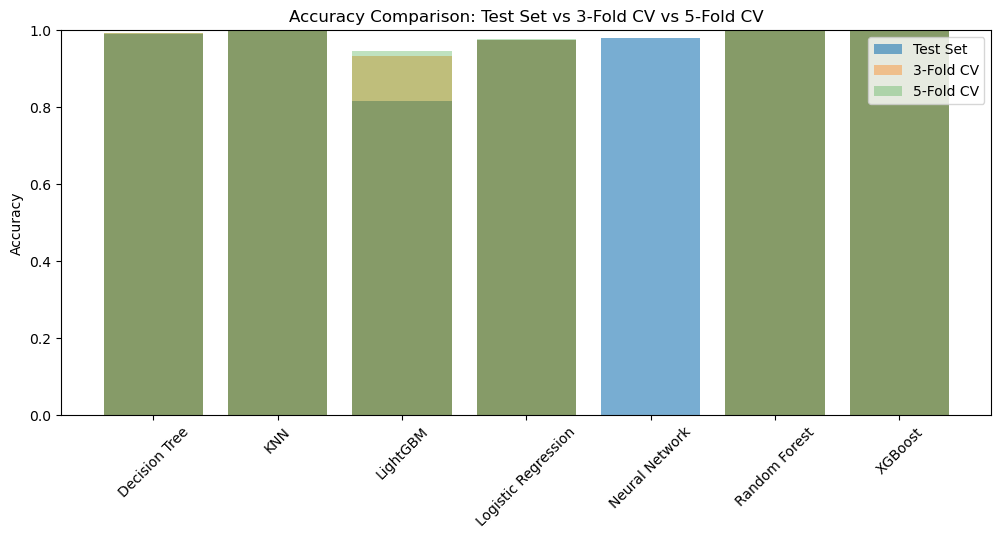

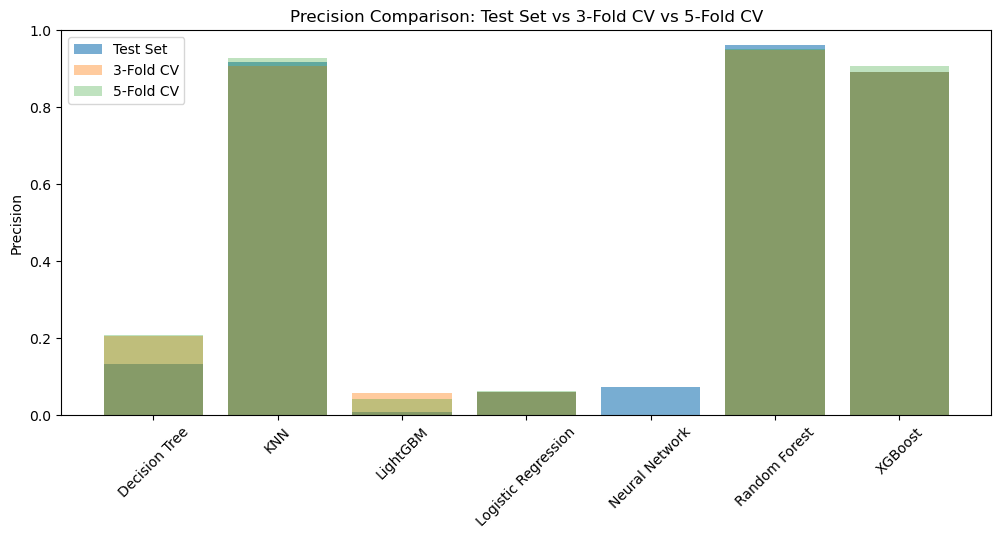

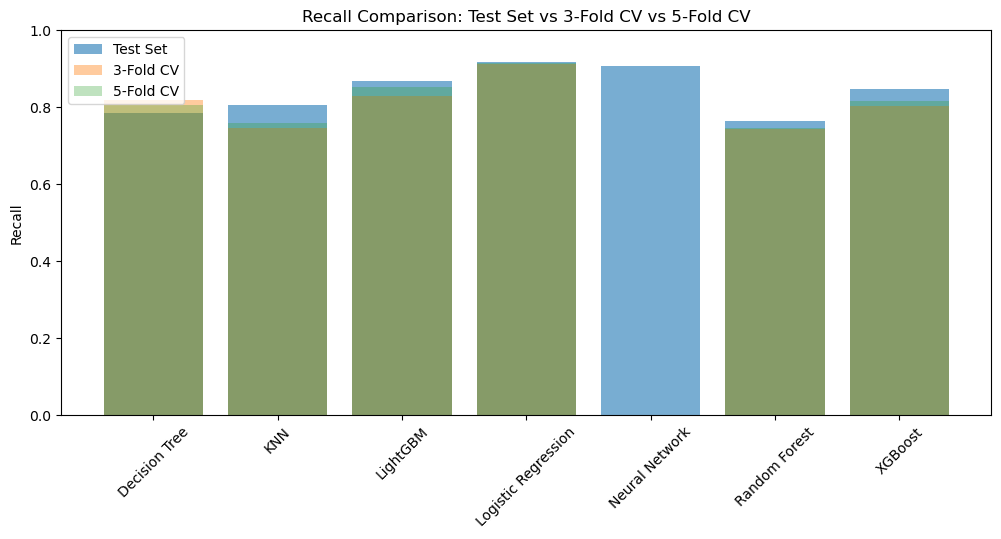

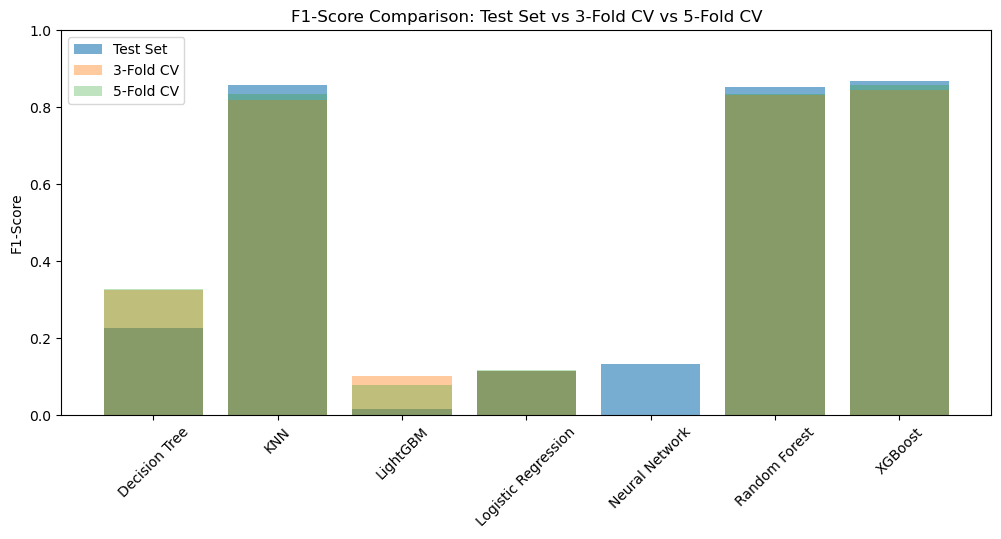

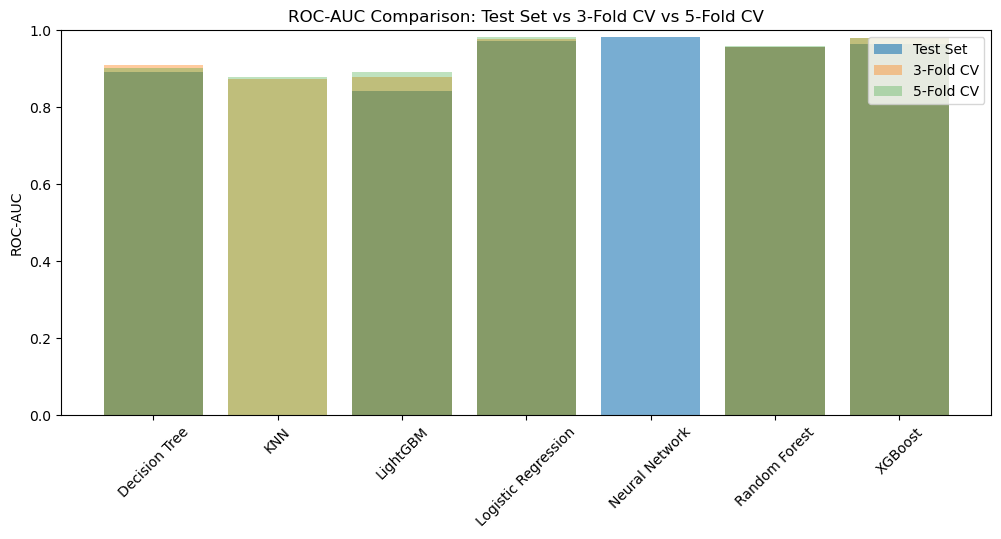

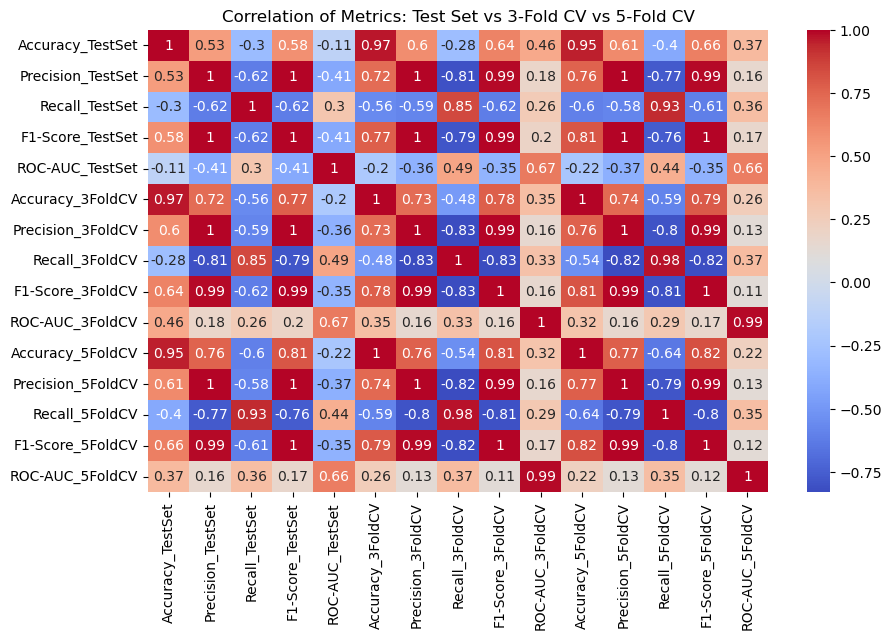

In [55]:
# Merge all metrics: Test Set, 3-Fold CV, 5-Fold CV
# Assume:
#   metrics_df       -> test set metrics
#   cv_results       -> 3-Fold CV metrics
#   cv_5fold_results -> 5-Fold CV metrics (already saved)

comparison_all = metrics_df.merge(cv_results, on="Model", how="outer", suffixes=("_TestSet","_3FoldCV"))
comparison_all = comparison_all.merge(cv_5fold_results, on="Model", how="outer")
# Rename 5-fold columns
comparison_all = comparison_all.rename(columns={
    "Accuracy":"Accuracy_5FoldCV",
    "Precision":"Precision_5FoldCV",
    "Recall":"Recall_5FoldCV",
    "F1-Score":"F1-Score_5FoldCV",
    "ROC-AUC":"ROC-AUC_5FoldCV"
})

# Show combined table
print("=== Test Set vs 3-Fold CV vs 5-Fold CV Metrics ===")
print(comparison_all)

# -----------------------------
# Bar chart: comparison
# -----------------------------
metrics_to_plot = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(12,5))
    plt.bar(comparison_all['Model'], comparison_all[f"{metric}_TestSet"], alpha=0.6, label="Test Set")
    plt.bar(comparison_all['Model'], comparison_all[f"{metric}_3FoldCV"], alpha=0.4, label="3-Fold CV")
    plt.bar(comparison_all['Model'], comparison_all[f"{metric}_5FoldCV"], alpha=0.3, label="5-Fold CV")
    plt.title(f"{metric} Comparison: Test Set vs 3-Fold CV vs 5-Fold CV")
    plt.ylabel(metric)
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

# -----------------------------
# Heatmap of correlations
# -----------------------------
plt.figure(figsize=(10,6))
all_metric_cols = [f"{m}_TestSet" for m in metrics_to_plot] + \
                  [f"{m}_3FoldCV" for m in metrics_to_plot] + \
                  [f"{m}_5FoldCV" for m in metrics_to_plot]
sns.heatmap(comparison_all[all_metric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Metrics: Test Set vs 3-Fold CV vs 5-Fold CV")
plt.show()
